In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
dockerDF = pd.read_csv('docker-gpuData.csv')

hostDF = pd.read_csv('host-gpuData.csv')

In [16]:
print(dockerDF.columns)

print(hostDF.columns)

Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf',
       'hpPerf', 'xtime', 'Block Size', 'Grid Size', 'device', 'SP_FLOP',
       'DP_FLOP', 'HP_FLOP', 'INTOP', 'intPerf', 'intAI', 'targetName',
       'exeArgs', 'runtime', 'kernelMangled', 'kernelName', 'kernelDemangled',
       'kernelProfiler'],
      dtype='object')
Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf',
       'hpPerf', 'xtime', 'Block Size', 'Grid Size', 'device', 'SP_FLOP',
       'DP_FLOP', 'HP_FLOP', 'INTOP', 'intPerf', 'intAI', 'targetName',
       'exeArgs', 'runtime', 'kernelMangled', 'kernelName', 'kernelDemangled',
       'kernelProfiler'],
      dtype='object')


In [17]:
print(hostDF.iloc[0])

source                                                  accuracy-cuda
exePath             /home/gbolet/gpuFLOPBench-updated/build/bin/cu...
kernel_executed                                                normal
eteProfilerXtime                                             2.477656
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           647016710642.040039
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf                                                            0.0
hpPerf                                                            0.0
xtime                                                        509376.0
Block Size          

In [18]:
print(dockerDF.iloc[0])

source                                                  accuracy-cuda
exePath                            /workspace/build/bin/cuda/accuracy
kernel_executed                                                normal
eteProfilerXtime                                             2.490934
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           646258894396.689941
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf                                                            0.0
hpPerf                                                            0.0
xtime                                                        509984.0
Block Size          

In [19]:
# we want to align both dataframes based on the "kernelMangled" and "source" columns
mergedDF = pd.merge(hostDF, dockerDF, on=['kernelMangled', 'Kernel Name', 'kernelName', 'kernelDemangled', 
                                          'kernelProfiler', 'targetName', 'CC', 'runtime', 'source', 'exeArgs',
                                          'device', 'Block Size', 'Grid Size'], suffixes=('_host', '_docker'))

print(mergedDF.columns)
print(mergedDF.shape)

mergedDF.sort_values(by=['source'], ascending=True, inplace=True)

print(mergedDF.head(4))

print(mergedDF['kernel_executed_docker'].unique())

# drop any rows where kernel_executed_host or kernel_executed_docker is NOT "normal"
mergedDF = mergedDF[(mergedDF['kernel_executed_host'] == 'normal') & (mergedDF['kernel_executed_docker'] == 'normal')]
print(mergedDF.shape)

Index(['source', 'exePath_host', 'kernel_executed_host',
       'eteProfilerXtime_host', 'CC', 'Kernel Name', 'traffic_host',
       'dpAI_host', 'spAI_host', 'hpAI_host', 'dpPerf_host', 'spPerf_host',
       'hpPerf_host', 'xtime_host', 'Block Size', 'Grid Size', 'device',
       'SP_FLOP_host', 'DP_FLOP_host', 'HP_FLOP_host', 'INTOP_host',
       'intPerf_host', 'intAI_host', 'targetName', 'exeArgs', 'runtime',
       'kernelMangled', 'kernelName', 'kernelDemangled', 'kernelProfiler',
       'exePath_docker', 'kernel_executed_docker', 'eteProfilerXtime_docker',
       'traffic_docker', 'dpAI_docker', 'spAI_docker', 'hpAI_docker',
       'dpPerf_docker', 'spPerf_docker', 'hpPerf_docker', 'xtime_docker',
       'SP_FLOP_docker', 'DP_FLOP_docker', 'HP_FLOP_docker', 'INTOP_docker',
       'intPerf_docker', 'intAI_docker'],
      dtype='object')
(1457, 47)
          source                                       exePath_host  \
0  accuracy-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/c

In [20]:
# we want to drop rows where the "CC", "Kernel Name", and "traffic" columns are NULL
mergedDF = mergedDF.dropna(subset=['traffic_host', 'traffic_docker', 'CC', 'Kernel Name'])

print(mergedDF.shape)

(1073, 47)


['exePath_host', 'kernel_executed_host', 'eteProfilerXtime_host', 'traffic_host', 'dpAI_host', 'spAI_host', 'hpAI_host', 'dpPerf_host', 'spPerf_host', 'hpPerf_host', 'xtime_host', 'SP_FLOP_host', 'DP_FLOP_host', 'HP_FLOP_host', 'INTOP_host', 'intPerf_host', 'intAI_host']
['exePath_docker', 'kernel_executed_docker', 'eteProfilerXtime_docker', 'traffic_docker', 'dpAI_docker', 'spAI_docker', 'hpAI_docker', 'dpPerf_docker', 'spPerf_docker', 'hpPerf_docker', 'xtime_docker', 'SP_FLOP_docker', 'DP_FLOP_docker', 'HP_FLOP_docker', 'INTOP_docker', 'intPerf_docker', 'intAI_docker']
['DP_FLOP', 'HP_FLOP', 'INTOP', 'SP_FLOP', 'dpAI', 'dpPerf', 'eteProfilerXtime', 'exePath', 'hpAI', 'hpPerf', 'intAI', 'intPerf', 'kernel_executed', 'spAI', 'spPerf', 'traffic', 'xtime']
DP_FLOP
0    0.000000e+00
1    7.817741e+09
2    1.481511e+10
Name: DP_FLOP_host, dtype: float64
HP_FLOP
0    0.0
1    0.0
2    0.0
Name: HP_FLOP_host, dtype: float64
INTOP
0    5.629983e+08
1    7.015186e+09
2    1.476101e+10
Name: IN

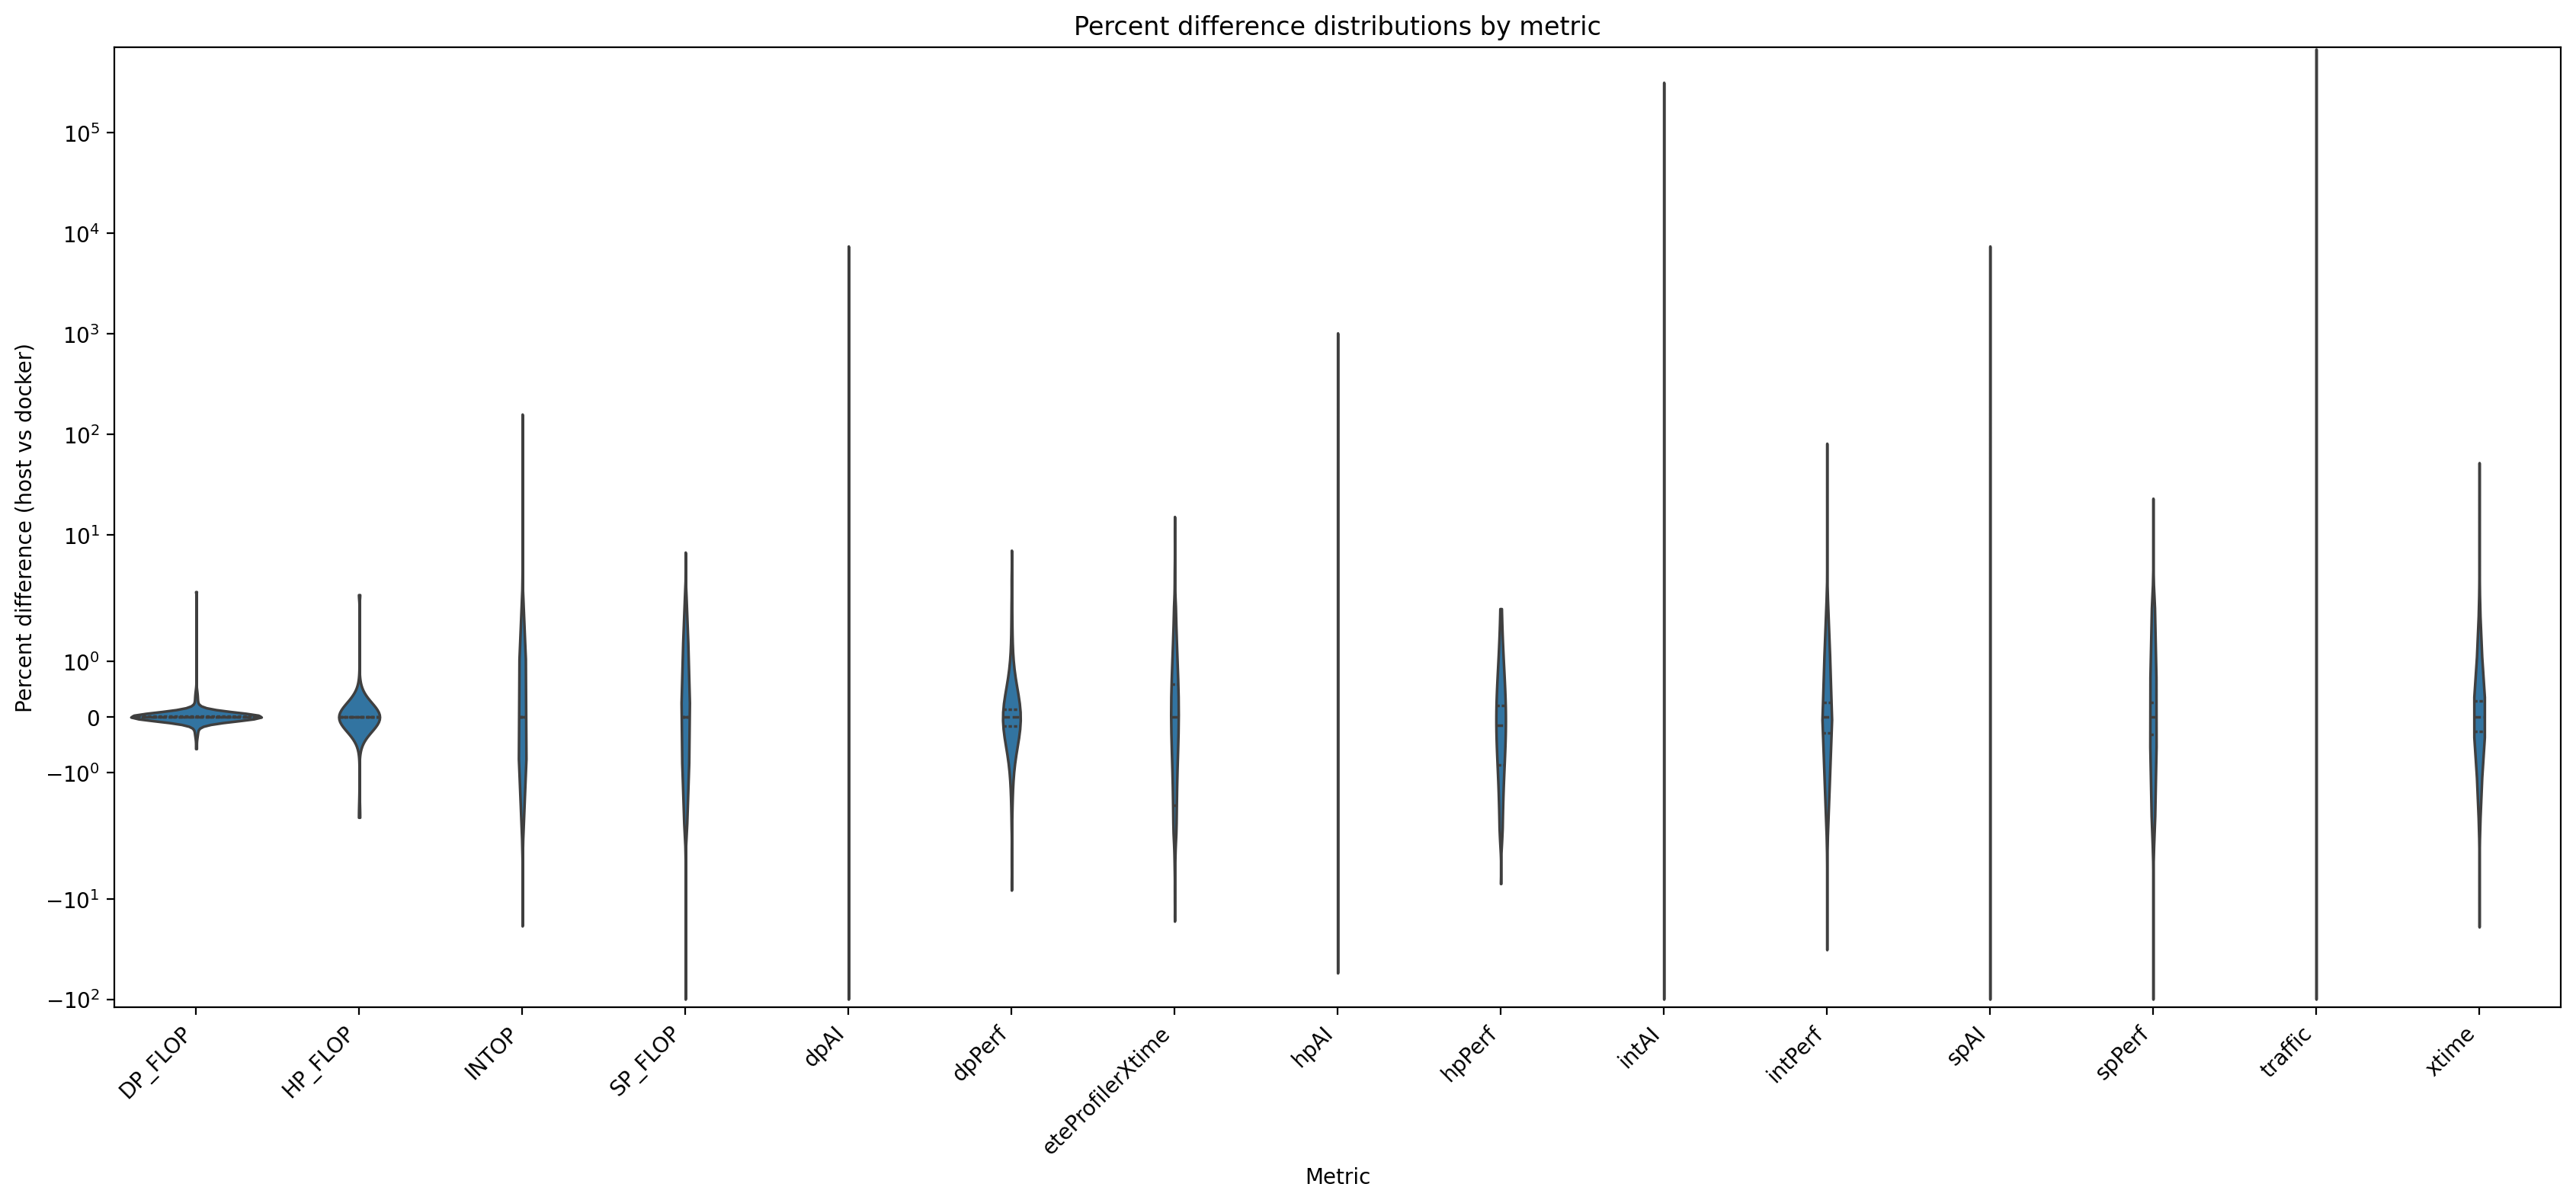

In [21]:
# make violin seaborn plots here

# identify numeric *_host / *_docker pairs
host_cols = [c for c in mergedDF.columns if c.endswith('_host')]
docker_cols = [c for c in mergedDF.columns if c.endswith('_docker')]

print(host_cols)
print(docker_cols)

base_cols = sorted(set(c[:-5] for c in host_cols).intersection(c[:-7] for c in docker_cols))

print(base_cols)

records = []
for base in base_cols:
    host_col = f"{base}_host"
    docker_col = f"{base}_docker"
    if host_col not in mergedDF.columns or docker_col not in mergedDF.columns:
        continue
    # ensure numeric and drop invalid rows
    host_vals = pd.to_numeric(mergedDF[host_col], errors='coerce')
    docker_vals = pd.to_numeric(mergedDF[docker_col], errors='coerce')

    print(base)
    print(host_vals.head(3))

    valid = (~host_vals.isna()) & (~docker_vals.isna()) 
    if valid.any():
        pct_diff = (host_vals[valid] - docker_vals[valid]) / docker_vals[valid] * 100.0
        records.append(pd.DataFrame({"metric": base, "pct_diff": pct_diff}))

if not records:
    print("No matching *_host/*_docker numeric columns found for plotting.")
else:
    plot_df = pd.concat(records, ignore_index=True)
    plt.figure(figsize=(max(8, len(base_cols)), 8), dpi=200)
    ax = sns.violinplot(data=plot_df, x="metric", y="pct_diff", inner="quartile", cut=0)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Percent difference (host vs docker)")
    ax.set_title("Percent difference distributions by metric")

    ax.set_yscale("symlog")
    ax.set_ylim(bottom=-120)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()